In [70]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import re
import math
from networkx.algorithms.community import greedy_modularity_communities


print("All libraries loaded")

All libraries loaded


In [7]:
import sys
sys.path.append('/Users/jasmi/capstone')

In [8]:
import os
print(os.getcwd())

c:\Users\jasmi\capstone\models\attribution


In [3]:
df = pd.read_csv("../../data/data/final_model_dataset.csv")
attr_df = pd.read_csv("../../data/attribution_all_scored.csv")

In [13]:
df.head()

,tag_name,article_id,source_feed_name,load_date,feed_name,author_name,source_unique_id,source_type_name,channel_name,genre,...,sentiment_band,hit_strength,vipr_weight,vipr_score,processed_headline,processed_body,headline_token_count,body_token_count,pub_credit_share,max_term_credit
0,Public Health,18083066685,regionals-web,2024-03-25,opoint,Jamie DeLine,31229-477204,Regional News,Web,Unknown,...,Neutral,2,685,-4795,lawmaker call independent report ny pandemic r...,albany news new york state capitol monday lost...,7,237,0.000326,0.056167
1,Public Health,18083068112,regionals-web,2024-03-25,opoint,Katherine Itoh,21944-341746,Regional News,Web,Unknown,...,Neutral,3,1300,-3900,yellowstone star forrie smith say kicked fligh...,forrie smith vocal public health belief skippe...,12,227,0.000484,0.084305
2,Public Health,18083069120,trade-web,2024-03-25,opoint,uncredited,156350-188089,Trade News,Web,Unknown,...,Neutral,13,2418,16926,free rsv immunisation program queensland infan...,joint statement premier honourable steven mile...,8,571,0.000938,0.177204
3,Public Health,18083073191,broadcast-tv,2024-03-25,tveyes,uncredited,a7a238b1-8e47-43f1-b27d-db271714b0e9,TV,Broadcast,WFTX,...,Negative,2,133,-5187,fox news,local news sport weather dark purple state one...,2,321,0.000000,0.134319
4,Public Health,18083073192,broadcast-tv,2024-03-25,tveyes,uncredited,36c13958-e8cf-4b90-9713-4c3838eed8f4,TV,Broadcast,WFTXBACK,...,Negative,2,133,-5187,fox news,local news sport weather dark purple state one...,2,321,0.000000,0.134319


In [14]:
attr_df.head()

,kind,dimension,value,credit,credit_share,rating,rating_pct
0,item,source_feed_name,broadcast-tv,0.925621,0.232353,5,1.000000
1,item,source_feed_name,regionals-web,0.863526,0.216765,5,0.891913
2,item,source_feed_name,broadcast-radio,0.405403,0.101766,5,0.094476
3,item,source_feed_name,consumer,0.402641,0.101072,5,0.089668
4,item,source_feed_name,web,0.351127,0.088141,5,0.000000


In [ ]:
# === Influence Network: concise static plot (uses attr_df) ====================
# What this does (brief):
# - Takes your unified attribution table (attr_df) with columns:
#   kind, dimension, value, credit, credit_share, rating, rating_pct
# - Builds a directed graph: state/value  ->  <CONV> (edge weight = credit_share or credit)
# - Plots a concise static network:
#     color = dimension, shape = kind (● item, ▲ term),
#     node size ≈ credit_share, edge width ≈ weight,
#     labels only for nodes above a threshold to avoid clutter.

In [16]:
SINK_LABEL = "<CONV>"
DIMENSION_COLORS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]
KIND_MARKERS = {"item": "o", "term": "^"}  # circle, triangle

# ---- prep & helpers ----
def prep_attr_df(df: pd.DataFrame) -> pd.DataFrame:
    required = {"kind","dimension","value","credit","credit_share","rating","rating_pct"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"attr_df missing required columns: {sorted(missing)}")
    out = df.copy()
    out["kind"] = out["kind"].astype(str)
    out["dimension"] = out["dimension"].astype(str)
    out["value"] = out["value"].astype(str)
    for c in ("credit","credit_share","rating_pct"):
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0)
    out["rating"] = pd.to_numeric(out["rating"], errors="coerce").fillna(0).astype(int)
    return out

def filter_top_per_dimension(df: pd.DataFrame, top_k: int | None = 50, min_share: float = 0.0) -> pd.DataFrame:
    x = df.copy()
    # filter by per-dimension share (credit_share) — classic behavior
    if min_share > 0:
        x = x[x["credit_share"] >= min_share]
    if top_k and top_k > 0:
        x = (
            x.sort_values(["dimension","credit_share"], ascending=[True, False])
             .groupby("dimension", as_index=False)
             .head(top_k)
        )
    return x.reset_index(drop=True)

def choose_labels_by_rank(G: nx.DiGraph, top_labels_per_dim: int = 10) -> dict:
    # rank by per-dimension credit_share stored on nodes
    by_dim = {}
    for n, d in G.nodes(data=True):
        if n == SINK_LABEL: 
            continue
        dim = d.get("dimension","other")
        by_dim.setdefault(dim, []).append((n, d.get("credit_share", 0.0)))
    labels = {}
    for dim, pairs in by_dim.items():
        pairs.sort(key=lambda t: t[1], reverse=True)
        for n,_ in pairs[:top_labels_per_dim]:
            labels[n] = n
    return labels

In [22]:
def build_graph_classic(attr_df: pd.DataFrame) -> nx.DiGraph:
    df = prep_attr_df(attr_df)

    # colors by dimension (fixed order)
    dims = sorted(df["dimension"].unique())
    dim_to_color = {d: DIMENSION_COLORS[i % len(DIMENSION_COLORS)] for i, d in enumerate(dims)}

    # one node per (value,kind,dimension) with summed metrics
    nodes_tbl = (
        df.groupby(["value","kind","dimension"], as_index=False)
          .agg({"credit":"sum","credit_share":"sum","rating":"max","rating_pct":"max"})
    )

    G = nx.DiGraph()

    # nodes: size = linear in credit_share (classic)
    for _, r in nodes_tbl.iterrows():
        node_id = r["value"]
        color = dim_to_color.get(r["dimension"], "#7f7f7f")
        size = max(80, float(r["credit_share"]) * 2200)
        G.add_node(
            node_id,
            kind=r["kind"], dimension=r["dimension"], color=color, size=size,
            credit=float(r["credit"]), credit_share=float(r["credit_share"]),
            rating=int(r["rating"]), rating_pct=float(r["rating_pct"])
        )

    # sink node
    if SINK_LABEL not in G:
        G.add_node(SINK_LABEL, kind="sink", dimension="conversion", color="#222222", size=500)

    # edges: weight = linear credit_share (classic)
    edge_tbl = df.groupby("value", as_index=False)["credit_share"].sum().rename(columns={"credit_share":"edge_weight"})
    for _, r in edge_tbl.iterrows():
        w = float(r["edge_weight"])
        if w > 0:
            G.add_edge(r["value"], SINK_LABEL, weight=w)

    return G

# ---- plot (spring layout, linear edge width, rank labels) ----
def draw_static_classic(G: nx.DiGraph, figsize=(12,8), top_labels_per_dim: int = 10):
    pos = nx.spring_layout(G, k=0.6, seed=42)  # classic, reproducible

    plt.figure(figsize=figsize)

    # edges: linear thickness
    widths = [max(0.5, G[u][v].get("weight", 0.0) * 6) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.25, arrows=True, arrowstyle="-|>", arrowsize=10)

    # nodes by kind (marker), colors by dimension
    for kind, marker in KIND_MARKERS.items():
        nodes_k = [n for n, d in G.nodes(data=True) if d.get("kind")==kind]
        sizes  = [G.nodes[n].get("size",120) for n in nodes_k]
        colors = [G.nodes[n].get("color","#7f7f7f") for n in nodes_k]
        nx.draw_networkx_nodes(G, pos, nodelist=nodes_k, node_size=sizes, node_color=colors,
                               node_shape=marker, linewidths=0.8, edgecolors="#333", alpha=0.95)

    # sink
    if SINK_LABEL in G:
        nx.draw_networkx_nodes(G, pos, nodelist=[SINK_LABEL], node_size=700,
                               node_color="#222222", node_shape="s",
                               linewidths=0.8, edgecolors="#111111")

    # labels: top-N per dimension by credit_share
    labels = choose_labels_by_rank(G, top_labels_per_dim=top_labels_per_dim)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    plt.title("Influence Network: Actors & Terms Driving Conversion", fontsize=14, pad=10)
    subtitle = "Color = dimension • Shape = kind (● item, ▲ term) • Size ≈ credit_share • Edge width ≈ credit_share"
    plt.suptitle(subtitle, y=0.88, fontsize=9, color="#444")

    kind_handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#777', markeredgecolor='#333', label='item', markersize=8),
        Line2D([0],[0], marker='^', color='w', markerfacecolor='#777', markeredgecolor='#333', label='term', markersize=8),
        Line2D([0],[0], marker='s', color='w', markerfacecolor='#222', markeredgecolor='#111', label='<CONV>', markersize=8),
    ]
    plt.legend(handles=kind_handles, loc='lower left', frameon=True, title='Kind')

    plt.axis("off")
    plt.tight_layout()
    plt.show()

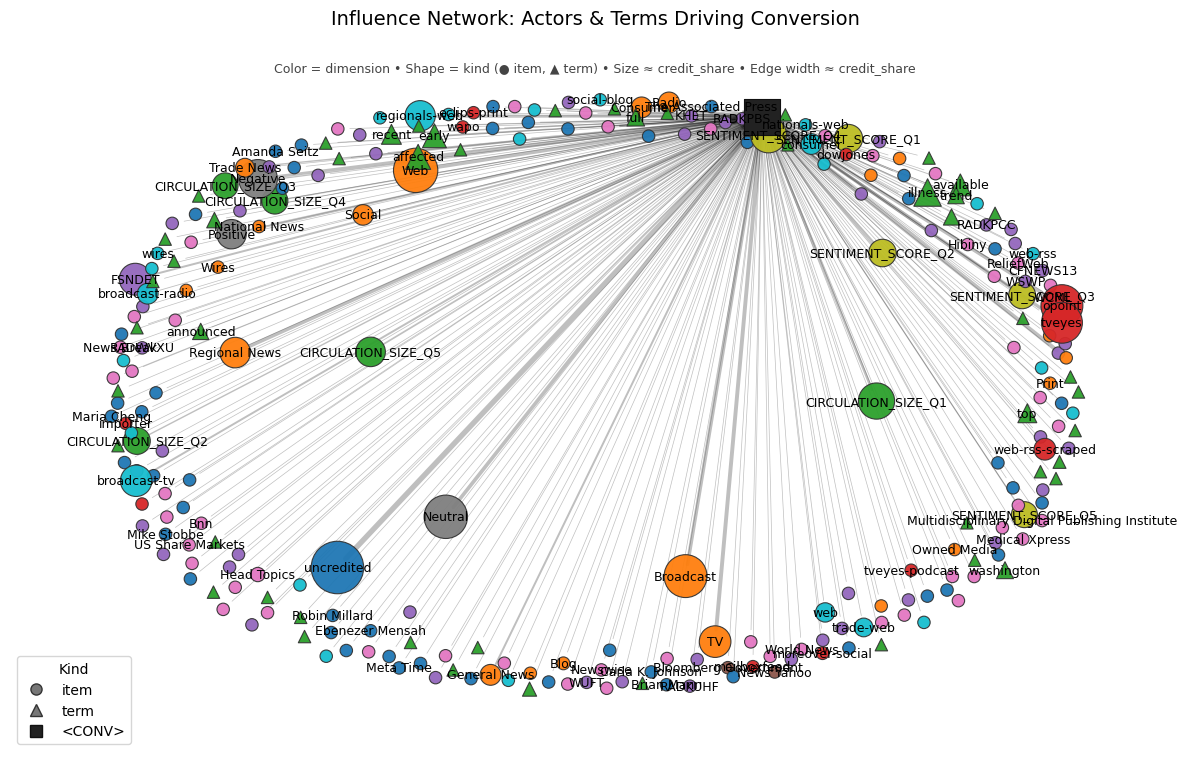

In [23]:
_attr = prep_attr_df(attr_df)
_attr_trim = filter_top_per_dimension(_attr, top_k=50, min_share=0.0)

# 2) Build & plot
G = build_graph_classic(_attr_trim)
draw_static_classic(G, figsize=(12, 8), top_labels_per_dim=10)

In [19]:
# ===========================
# TABLE COMPARISON (TERMS)
# ===========================
def prep_terms_for_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out[out["kind"] == "term"].copy()
    out["credit"] = pd.to_numeric(out["credit"], errors="coerce").fillna(0.0)
    out["credit_share"] = pd.to_numeric(out["credit_share"], errors="coerce").fillna(0.0)
    out["value"] = out["value"].astype(str)
    return out

def add_global_term_share(df_terms: pd.DataFrame) -> pd.DataFrame:
    total = df_terms["credit"].sum()
    df_terms = df_terms.copy()
    df_terms["credit_share_global"] = df_terms["credit"] / total if total > 0 else 0.0
    return df_terms

def top_terms(df_terms: pd.DataFrame, field: str, n: int = 20) -> pd.DataFrame:
    tbl = (df_terms.groupby("value", as_index=False)[field]
                   .sum()
                   .sort_values(field, ascending=False)
                   .head(n))
    tbl.insert(0, "rank", range(1, len(tbl) + 1))
    return tbl

_terms = prep_terms_for_table(attr_df)
_terms = add_global_term_share(_terms)

top_chunk  = top_terms(_terms, "credit_share", n=20).rename(columns={
    "rank":"rank_chunk", "credit_share":"credit_share_chunk"
})
top_global = top_terms(_terms, "credit_share_global", n=20).rename(columns={
    "rank":"rank_global", "credit_share_global":"credit_share_global"
})

# Merge to compare ranks & values; keep union of top-20 in each mode
compare = pd.merge(top_chunk, top_global, on="value", how="outer")

# Fill missing ranks with something large, so diffs make sense
max_rank = 999
compare["rank_chunk"]  = compare["rank_chunk"].fillna(max_rank).astype(int)
compare["rank_global"] = compare["rank_global"].fillna(max_rank).astype(int)
compare["credit_share_chunk"]  = compare["credit_share_chunk"].fillna(0.0)
compare["credit_share_global"] = compare["credit_share_global"].fillna(0.0)

# Rank change (negative = moved up globally)
compare["rank_delta"] = compare["rank_global"] - compare["rank_chunk"]
compare["share_delta"] = compare["credit_share_global"] - compare["credit_share_chunk"]

# Nice sort: best global rank first, then chunk rank
compare = compare.sort_values(["rank_global", "rank_chunk"]).reset_index(drop=True)

print("Top 20 Terms — CHUNK-normalized")
display(top_chunk)

print("Top 20 Terms — GLOBAL-normalized")
display(top_global)

print("Comparison (union of Top 20s) — rank/weight changes")
display(compare[
    ["value", "rank_chunk", "rank_global", "rank_delta",
     "credit_share_chunk", "credit_share_global", "share_delta"]
])

Top 20 Terms — CHUNK-normalized


,rank_chunk,value,credit_share_chunk
164,1,illness,0.177204
9,2,affected,0.147297
100,3,early,0.134319
33,4,available,0.112737
296,5,recent,0.093094
364,6,top,0.084305
137,7,full,0.073392
382,8,washington,0.067504
368,9,trend,0.065117
22,10,announced,0.062652


Top 20 Terms — GLOBAL-normalized


,rank_global,value,credit_share_global
164,1,illness,0.088602
9,2,affected,0.073649
100,3,early,0.067160
33,4,available,0.056368
296,5,recent,0.046547
364,6,top,0.042153
137,7,full,0.036696
382,8,washington,0.033752
368,9,trend,0.032559
22,10,announced,0.031326


Comparison (union of Top 20s) — rank/weight changes


,value,rank_chunk,rank_global,rank_delta,credit_share_chunk,credit_share_global,share_delta
0,illness,1,1,0,0.177204,0.088602,-0.088602
1,affected,2,2,0,0.147297,0.073649,-0.073649
2,early,3,3,0,0.134319,0.067160,-0.067160
3,available,4,4,0,0.112737,0.056368,-0.056368
4,recent,5,5,0,0.093094,0.046547,-0.046547
5,top,6,6,0,0.084305,0.042153,-0.042153
6,full,7,7,0,0.073392,0.036696,-0.036696
7,washington,8,8,0,0.067504,0.033752,-0.033752
8,trend,9,9,0,0.065117,0.032559,-0.032559
9,announced,10,10,0,0.062652,0.031326,-0.031326


In [ ]:
# ============================================================
# Publisher ↔ Term Content Network 
# ------------------------------------------------------------
# What this does (brief):
# - Builds a bipartite graph between publishers and their
#   articles' most influential term.
# - "Most influential term" per article is the matched term
#   whose global credit_share (from attr_df where kind=='term')
#   is highest among terms present in the article text.
# - Node size:
#     • publisher: number of matched articles (degree, weighted)
#     • term: total matched weight across publishers
# - Edge weight: sum of matched term weights between that
#   publisher and term (stronger association = thicker edge)
# - Visual: circles (publishers), triangles (terms), spring layout,
#   labels for top-N per type to keep it readable.

In [31]:
def _ensure_cols_present(table, cols, name):
    missing = [c for c in cols if c not in table.columns]
    if missing:
        raise ValueError(f"{name} missing required columns: {missing}")

_ensure_cols_present(df, ["publisher_name","processed_headline","processed_body"], "df")
_ensure_cols_present(attr_df, ["kind","value","credit_share"], "attr_df")

# Clean basic types
df_use = df.copy()
df_use["publisher_name"] = df_use["publisher_name"].astype(str).fillna("Unknown")
for c in ["processed_headline","processed_body"]:
    df_use[c] = df_use[c].fillna("").astype(str)

# --------- Build term score table from attr_df (global) ----------
term_scores = (
    attr_df.query("kind=='term'")
           .loc[:, ["value","credit_share"]]
           .dropna()
           .rename(columns={"value":"term","credit_share":"term_weight"})
           .sort_values("term_weight", ascending=False)
           .reset_index(drop=True)
)

# --------- Finder: best (term, weight) present in a text ----------
def compile_term_patterns(terms):
    # whole-word-ish match, case-insensitive; escape special chars
    return [re.compile(rf"\b{re.escape(t)}\b", flags=re.IGNORECASE) for t in terms]

def best_term_for_text(text, ranked_terms, patterns):
    """Return (best_term, best_weight) present in 'text' or (None, 0.0).
       ranked_terms: list of (term, weight), sorted desc by weight
       patterns:     list of compiled regex, aligned 1:1 with ranked_terms
    """
    # iterate in ranked order; first hit is the best
    for (t, w), pat in zip(ranked_terms, patterns):
        if pat.search(text):
            return t, float(w)
    return None, 0.0

In [ ]:
# --------- Build edges: publisher ↔ best_term ----------
def build_publisher_term_edges(
    articles: pd.DataFrame,
    term_table: pd.DataFrame,
    term_limit: int = 500,
    min_term_weight: float = 0.0
) -> pd.DataFrame:
    """
    Returns edge table with columns: publisher, term, weight
    weight = sum of best_term weight across that publisher's matched articles.
    Only matches among top 'term_limit' terms by weight are considered for speed.
    """
    tt = term_table.head(term_limit).copy()
    ranked_terms = list(tt.itertuples(index=False, name=None))  # (term, weight)
    patterns = compile_term_patterns([t for t,_ in ranked_terms])

    edges = {}
    for _, r in articles.iterrows():
        txt = f"{r['processed_headline']} {r['processed_body']}"
        best_t, best_w = best_term_for_text(txt, ranked_terms, patterns)
        if best_t is None or best_w < min_term_weight:
            continue
        key = (r["publisher_name"], best_t)
        edges[key] = edges.get(key, 0.0) + best_w

    if not edges:
        return pd.DataFrame(columns=["publisher","term","weight"])

    pub, term, w = zip(*[(p,t,v) for (p,t),v in edges.items()])
    return pd.DataFrame({"publisher": pub, "term": term, "weight": w})

# --------- Graph builder & plotter ----------
def build_bipartite_graph(edges: pd.DataFrame) -> nx.Graph:
    """
    Build an undirected bipartite graph:
      set A = publishers (type='publisher')
      set B = terms      (type='term')
    Edge weights = aggregated association strength.
    """
    G = nx.Graph()
    for _, r in edges.iterrows():
        p, t, w = r["publisher"], r["term"], float(r["weight"])
        if p not in G: G.add_node(p, ntype="publisher")
        if t not in G: G.add_node(t, ntype="term")
        if w > 0:
            G.add_edge(p, t, weight=w)
    return G

def draw_publisher_term_network(
    G: nx.Graph,
    top_labels_per_type: int = 12,
    figsize=(14, 9)
):
    # size nodes by (weighted) degree
    def node_strength(n):
        return sum(G[n][nbr].get("weight", 0.0) for nbr in G.neighbors(n))

    strengths = {n: node_strength(n) for n in G.nodes()}
    max_strength = max(strengths.values()) if strengths else 1.0

    # scale sizes (nonlinear to spread)
    def scale(s): return max(80.0, (s / max_strength) ** 0.65 * 3000.0)
    sizes = [scale(strengths[n]) for n in G.nodes()]

    # colors & shapes by type
    color_map = {"publisher": "#1f77b4", "term": "#ff7f0e"}
    shape_map = {"publisher": "o", "term": "^"}
    node_types = nx.get_node_attributes(G, "ntype")
    node_colors = [color_map.get(node_types.get(n, "publisher"), "#7f7f7f") for n in G.nodes()]

    # layout (weighted for clarity)
    pos = nx.spring_layout(G, k=0.6, seed=42, weight="weight")

    plt.figure(figsize=figsize)

    # edges: thickness by weight (sqrt for contrast)
    widths = [max(0.5, (G[u][v].get("weight", 0.0) ** 0.5) * 6) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.25)

    # draw nodes by type (for shapes)
    for t, marker in shape_map.items():
        nodes_t = [n for n in G.nodes() if node_types.get(n) == t]
        sizes_t = [sizes[list(G.nodes()).index(n)] for n in nodes_t]
        colors_t = [node_colors[list(G.nodes()).index(n)] for n in nodes_t]
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodes_t, node_size=sizes_t, node_color=colors_t,
            node_shape=marker, linewidths=0.8, edgecolors="#333", alpha=0.95
        )

    # labels: top-N publishers and top-N terms by strength
    pubs = [n for n in G.nodes() if node_types.get(n) == "publisher"]
    terms = [n for n in G.nodes() if node_types.get(n) == "term"]
    pubs_top = sorted(pubs, key=lambda n: strengths[n], reverse=True)[:top_labels_per_type]
    terms_top = sorted(terms, key=lambda n: strengths[n], reverse=True)[:top_labels_per_type]
    labels = {n: n for n in pubs_top + terms_top}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    # title + legend
    plt.title("Content Network: Publishers ↔ Highest-Impact Terms (per article)", fontsize=14, pad=10)
    subtitle = "Circle = publisher • Triangle = term • Node size ≈ weighted degree • Edge width ≈ association strength"
    plt.suptitle(subtitle, y=0.80, fontsize=9, color="#444")

    legend_handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=color_map["publisher"],
               markeredgecolor='#333', label='publisher', markersize=8),
        Line2D([0],[0], marker='^', color='w', markerfacecolor=color_map["term"],
               markeredgecolor='#333', label='term', markersize=8),
    ]
    plt.legend(handles=legend_handles, loc='upper left', frameon=True, title='Node type')

    plt.axis("off")
    plt.tight_layout()
    plt.show()

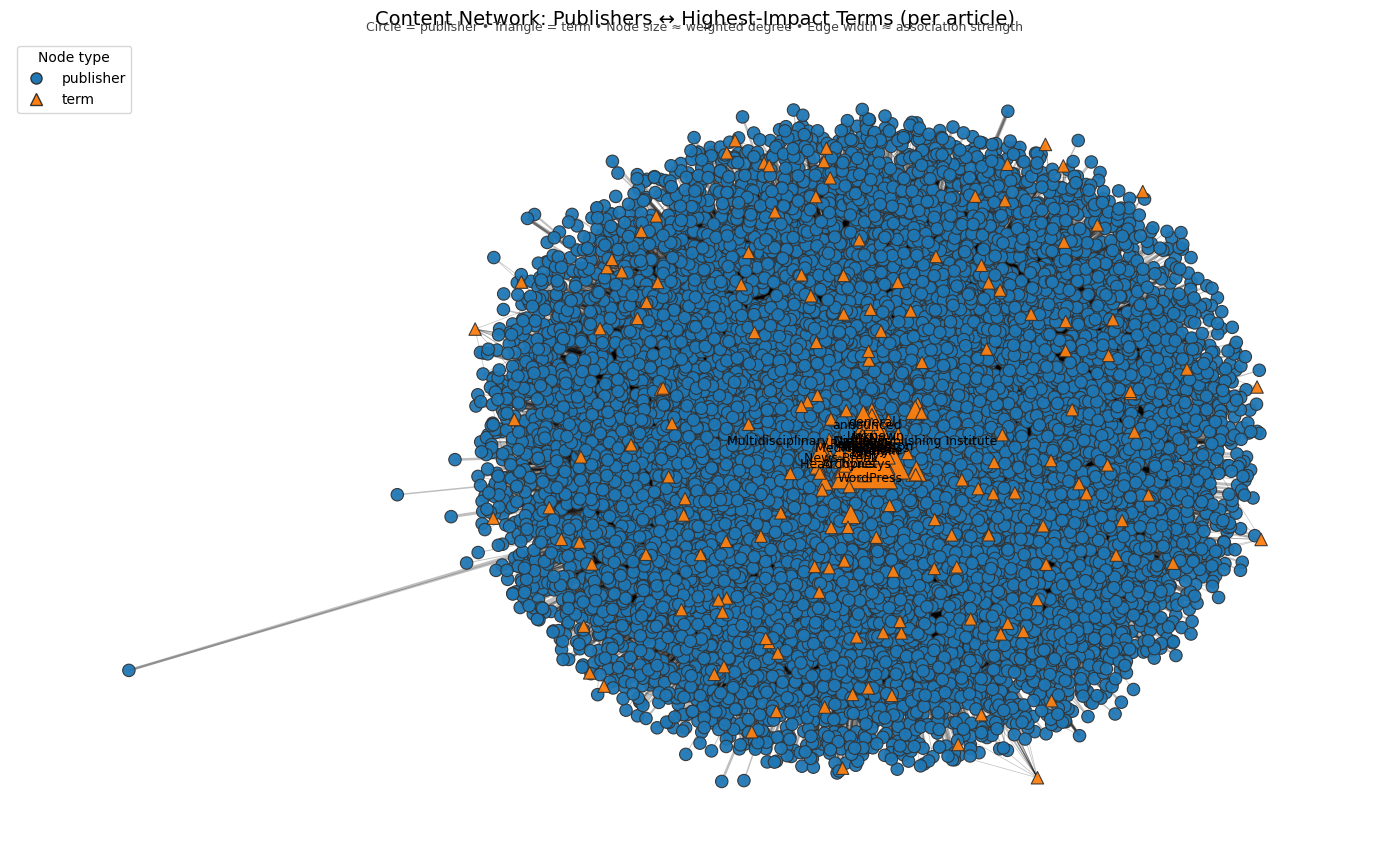

,Publisher,Term,AssocWeight
5,WordPress,illness,126.878388
190,Multidisciplinary Digital Publishing Institute,illness,120.144619
782,Multidisciplinary Digital Publishing Institute,affected,109.589100
10960,Archyde,illness,98.525675
1471,Multidisciplinary Digital Publishing Institute,early,77.099289
15,WordPress,early,66.891021
3611,Archynetys,illness,65.211238
30,World News,full,63.337580
32345,Archynewsy,illness,60.781127
1848,WordPress,affected,50.081040


In [33]:
TERM_LIMIT = 200          # only match among the top-N terms by global weight (speed + precision)
MIN_TERM_WEIGHT = 0.0     # ignore terms whose global weight is below this
TOP_LABELS_PER_TYPE = 12  # labels per node type in the plot

# --------------------------
# RUN
# --------------------------
edges = build_publisher_term_edges(
    articles=df_use,
    term_table=term_scores,
    term_limit=TERM_LIMIT,
    min_term_weight=MIN_TERM_WEIGHT
)

G_content = build_bipartite_graph(edges)
draw_publisher_term_network(G_content, top_labels_per_type=TOP_LABELS_PER_TYPE, figsize=(14, 9))

# Optional quick table to inspect top associations
display(
    edges.sort_values("weight", ascending=False)
         .head(20)
         .rename(columns={"publisher":"Publisher","term":"Term","weight":"AssocWeight"})
)

In [59]:
PUBLISHER_COL = "publisher_name"
UNIGRAM_300_CSV = r"C:\Users\jasmi\capstone\data\processed\data\top_300_unigrams.csv"
BIGRAM_1K_CSV   = r"C:\Users\jasmi\capstone\data\processed\data\top_1000_bigrams.csv"
KEYWORDS_1K_CSV = r"C:\Users\jasmi\capstone\data\processed\data\top_1000_keywords.csv"
WORDS_1K_CSV    = r"C:\Users\jasmi\capstone\data\processed\data\top_1000_words.csv"

In [60]:
WHITELIST_CAP   = 1500   # e.g., 1500 to cap number of terms (None = keep all)
MIN_TERM_WEIGHT = 0.001    # ignore matched terms with global weight below this
TOP_LABELS      = 12     # labels per node type in the plot
FIGSIZE         = (14, 9)

# ----------------------------
# Basic checks & prep
# ----------------------------
need_df_cols = {PUBLISHER_COL, "processed_headline", "processed_body"}
missing = need_df_cols - set(df.columns)
if missing:
    raise ValueError(f"`df` missing columns: {sorted(missing)}")

if not {"kind","value","credit_share"} <= set(attr_df.columns):
    raise ValueError("`attr_df` must include ['kind','value','credit_share'].")

df_use = df.copy()
for c in [PUBLISHER_COL, "processed_headline", "processed_body"]:
    df_use[c] = df_use[c].fillna("").astype(str)
if "max_term_credit" not in df_use.columns:
    df_use["max_term_credit"] = 0.0
if "vipr_weight" not in df_use.columns:
    df_use["vipr_weight"] = 1.0

# ----------------------------
# Load whitelist (4 CSVs)
# ----------------------------
def _read_first_col(path: str) -> pd.Series:
    try:
        s = pd.read_csv(path, header=None).iloc[:, 0]
    except Exception:
        s = pd.read_csv(path).iloc[:, 0]
    return s.dropna().astype(str).str.strip()

parts = []
for p in [UNIGRAM_300_CSV, BIGRAM_1K_CSV, KEYWORDS_1K_CSV, WORDS_1K_CSV]:
    if p:
        parts.append(_read_first_col(p))
if not parts:
    raise ValueError("Provide valid paths to your whitelist CSVs.")

whitelist = pd.concat(parts, ignore_index=True)
# Deduplicate while preserving order
_seen = set(); whitelist = [t for t in whitelist if t and not (t in _seen or _seen.add(t))]

In [61]:
# Global term weights (attr_df)
# ----------------------------
term_w = (attr_df.query("kind=='term'")
          .loc[:, ["value", "credit_share"]]
          .rename(columns={"value": "term", "credit_share": "term_weight"}))

# Keep only whitelisted terms; supply weight=1.0 for any missing
term_w = term_w[term_w["term"].isin(whitelist)]
if term_w.empty:
    term_w = pd.DataFrame({"term": whitelist, "term_weight": 1.0})
else:
    missing_terms = set(whitelist) - set(term_w["term"])
    if missing_terms:
        term_w = pd.concat(
            [term_w, pd.DataFrame({"term": list(missing_terms), "term_weight": 1.0})],
            ignore_index=True
        )

# Optional cap by global weight
if WHITELIST_CAP:
    term_w = term_w.sort_values("term_weight", ascending=False).head(WHITELIST_CAP)
    whitelist = term_w["term"].tolist()

In [62]:
# FAST MATCHING via token sets
# ----------------------------
def prepare_whitelist_sets(whitelist_terms: list[str], term_weight_tbl: pd.DataFrame):
    # map term -> global weight (default 1.0)
    tw_map = {str(t): float(w) for t, w in term_weight_tbl[["term","term_weight"]].itertuples(index=False, name=None)}
    uni, bi = set(), set()
    for t in whitelist_terms:
        t = str(t).strip()
        if not t:
            continue
        if " " in t:
            bi.add(t.lower())
        else:
            uni.add(t.lower())
        if t not in tw_map:
            tw_map[t] = 1.0
    return uni, bi, tw_map

def bigram_strings(tokens: list[str]) -> set[str]:
    if len(tokens) < 2:
        return set()
    return {f"{a} {b}" for a, b in zip(tokens[:-1], tokens[1:])}

def best_term_from_tokens(tokens: list[str],
                          uni_whitelist: set[str],
                          bi_whitelist: set[str],
                          tw_map: dict[str, float],
                          min_weight: float = 0.0):
    tok_set = set(tokens)
    bi_set  = bigram_strings(tokens)

    matches = []
    # bigrams first (tend to be more specific)
    for t in bi_set.intersection(bi_whitelist):
        w = tw_map.get(t, 1.0)
        if w >= min_weight:
            matches.append((t, w))
    # unigrams
    for t in tok_set.intersection(uni_whitelist):
        w = tw_map.get(t, 1.0)
        if w >= min_weight:
            matches.append((t, w))

    if not matches:
        return None, 0.0

    # pick highest global weight; tie-breaker: longer term string
    matches.sort(key=lambda x: (x[1], len(x[0])), reverse=True)
    t, w = matches[0]
    return t, float(w)

uni_whitelist, bi_whitelist, TW_MAP = prepare_whitelist_sets(whitelist, term_w)

# ----------------------------
# Build edges (Publisher ↔ Term)
# ----------------------------
def build_edges_fast(articles: pd.DataFrame,
                     publisher_col: str = PUBLISHER_COL,
                     min_term_weight: float = MIN_TERM_WEIGHT) -> pd.DataFrame:
    edges = {}
    # lowercase once
    art = articles[[publisher_col, "processed_headline", "processed_body", "max_term_credit", "vipr_weight"]].copy()
    art[publisher_col] = art[publisher_col].replace("", "Unknown").fillna("Unknown").astype(str)
    for c in ["processed_headline", "processed_body"]:
        art[c] = art[c].fillna("").astype(str).str.lower()

    for _, r in art.iterrows():
        pub = r[publisher_col]
        tokens = (r["processed_headline"] + " " + r["processed_body"]).split()
        if not tokens:
            continue

        best_t, best_global_w = best_term_from_tokens(tokens, uni_whitelist, bi_whitelist, TW_MAP, min_weight=min_term_weight)
        if not best_t:
            continue

        # prefer article-level influence; fallback to global term weight × vipr_weight
        w_article = float(pd.to_numeric(r.get("max_term_credit", 0.0), errors="coerce") or 0.0)
        if w_article <= 0:
            w_article = best_global_w * float(pd.to_numeric(r.get("vipr_weight", 1.0), errors="coerce") or 1.0)

        key = (pub, best_t)
        edges[key] = edges.get(key, 0.0) + w_article

    if not edges:
        return pd.DataFrame(columns=["publisher","term","weight"])

    pub, term, w = zip(*[(p, t, v) for (p, t), v in edges.items()])
    return pd.DataFrame({"publisher": pub, "term": term, "weight": w})

edges = build_edges_fast(df_use, publisher_col=PUBLISHER_COL, min_term_weight=MIN_TERM_WEIGHT)

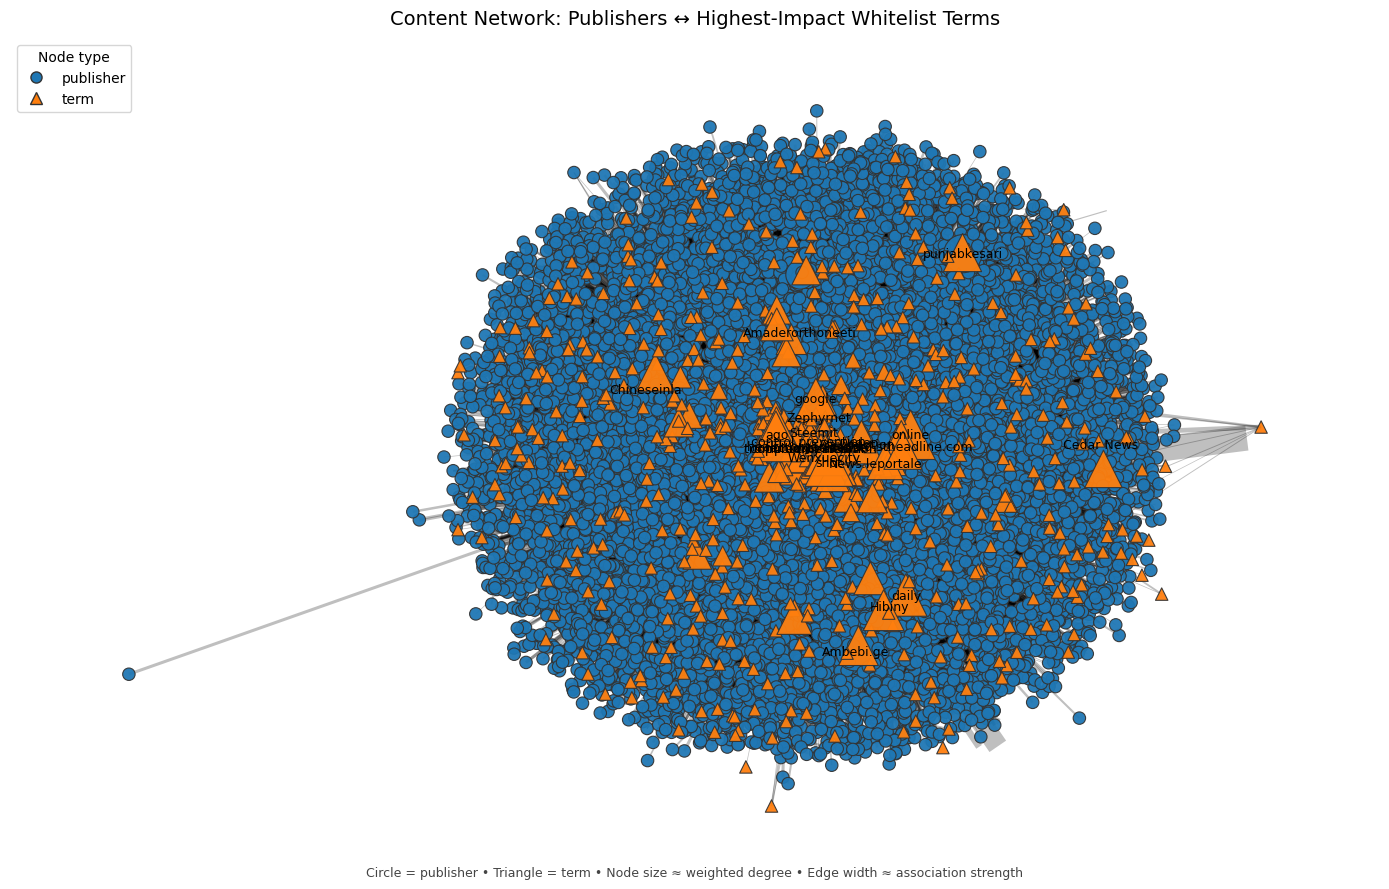

,Publisher,Term,AssocWeight
28659,Steemit,ago,3966.449590
56393,std.stheadline.com,online,2878.001394
91559,Wenxuecity,shot,2100.000000
90335,Hibiny,daily,1800.000000
10681,Zephyrnet,google,1644.093268
18948,Hibiny,big,1600.000000
38458,Wenxuecity,force,1600.000000
80238,Ambebi.ge,direct,1473.000000
87297,Wenxuecity,alert,1400.000000
79942,punjabkesari,link,1300.000000


In [63]:
# Graph + plot
# ----------------------------
def build_bipartite_graph(edges: pd.DataFrame) -> nx.Graph:
    G = nx.Graph()
    for _, r in edges.iterrows():
        p, t, w = r["publisher"], r["term"], float(r["weight"])
        if p not in G: G.add_node(p, ntype="publisher")
        if t not in G: G.add_node(t, ntype="term")
        if w > 0:
            G.add_edge(p, t, weight=w)
    return G

def draw_pub_term_network(G: nx.Graph, top_labels_per_type: int = TOP_LABELS, figsize=FIGSIZE):
    # node strength = sum of incident edge weights
    strength = {n: sum(G[n][nbr].get("weight", 0.0) for nbr in G.neighbors(n)) for n in G.nodes()}
    max_s = max(strength.values()) if strength else 1.0
    scale = lambda s: max(80.0, (s / max_s) ** 0.65 * 3000.0)

    ntype = nx.get_node_attributes(G, "ntype")
    color = {"publisher": "#1f77b4", "term": "#ff7f0e"}
    shape = {"publisher": "o", "term": "^"}

    pos = nx.spring_layout(G, k=0.6, seed=42, weight="weight")

    plt.figure(figsize=figsize)

    # edges
    widths = [max(0.5, (G[u][v]["weight"] ** 0.5) * 6) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.25)

    # nodes by type
    for t, marker in shape.items():
        nodes_t = [n for n in G.nodes() if ntype.get(n) == t]
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodes_t,
            node_size=[scale(strength[n]) for n in nodes_t],
            node_color=[color[t]] * len(nodes_t),
            node_shape=marker, linewidths=0.8, edgecolors="#333", alpha=0.95
        )

    # labels: top-N per type
    pubs = [n for n in G.nodes() if ntype.get(n) == "publisher"]
    terms = [n for n in G.nodes() if ntype.get(n) == "term"]
    pubs_top = sorted(pubs, key=lambda n: strength[n], reverse=True)[:top_labels_per_type]
    terms_top = sorted(terms, key=lambda n: strength[n], reverse=True)[:top_labels_per_type]
    labels = {n: n for n in pubs_top + terms_top}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    plt.title("Content Network: Publishers ↔ Highest-Impact Whitelist Terms", fontsize=14, pad=10)
    plt.figtext(0.5, 0.02,
                "Circle = publisher • Triangle = term • Node size ≈ weighted degree • Edge width ≈ association strength",
                ha="center", fontsize=9, color="#444")

    legend_handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=color["publisher"],
               markeredgecolor='#333', label='publisher', markersize=8),
        Line2D([0],[0], marker='^', color='w', markerfacecolor=color["term"],
               markeredgecolor='#333', label='term', markersize=8),
    ]
    plt.legend(handles=legend_handles, loc='upper left', frameon=True, title='Node type')
    plt.axis("off"); plt.tight_layout(); plt.show()

G_content = build_bipartite_graph(edges)
draw_pub_term_network(G_content)

# Quick table of strongest links
display(
    edges.sort_values("weight", ascending=False)
         .head(20)
         .rename(columns={"publisher":"Publisher","term":"Term","weight":"AssocWeight"})
)

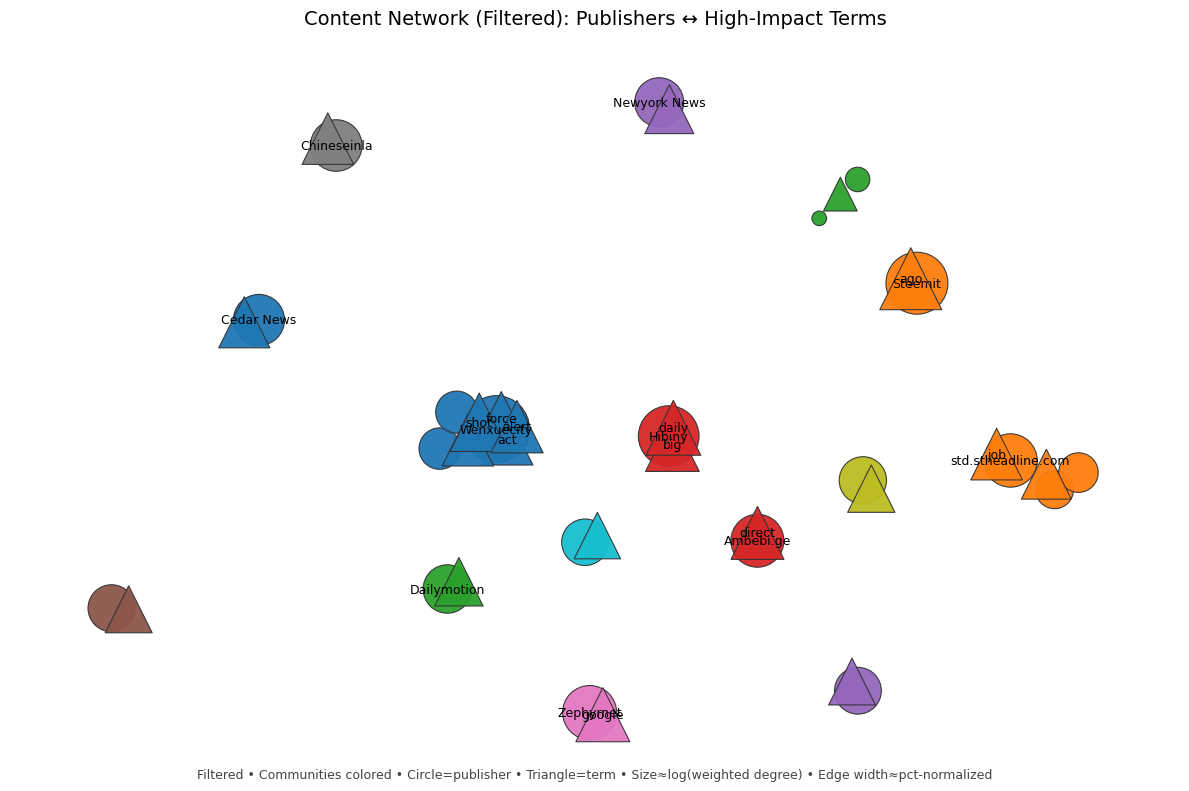

In [72]:
# -------- sensible defaults (wider lens) --------
TOP_PUBLISHERS   = 30
TOP_TERMS        = 30
EDGE_Q_CUTOFF    = 0.75   # keep edges >= 75th percentile weight within the subset
GENERIC_TERMS    = {"online","video","link"}  # start short; add more only if noisy
LABELS_PER_TYPE  = 10
FIGSIZE          = (12, 8)

# ---- 1) start from edges, prune obvious noise but keep structure ----
ef = edges.copy()
ef = ef[~ef["term"].isin(GENERIC_TERMS)].reset_index(drop=True)

# rank endpoints by weighted degree and keep top-N of each side
pub_strength  = ef.groupby("publisher")["weight"].sum().sort_values(ascending=False)
term_strength = ef.groupby("term")["weight"].sum().sort_values(ascending=False)
keep_pubs  = set(pub_strength.head(TOP_PUBLISHERS).index)
keep_terms = set(term_strength.head(TOP_TERMS).index)
ef = ef[ef["publisher"].isin(keep_pubs) & ef["term"].isin(keep_terms)].reset_index(drop=True)

# within this subset, drop the weakest edges by percentile
if not ef.empty:
    w_cut = ef["weight"].quantile(EDGE_Q_CUTOFF)
    ef = ef[ef["weight"] >= w_cut].reset_index(drop=True)

# ---- 2) build graph and color by communities ----
G = nx.Graph()
for _, r in ef.iterrows():
    p, t, w = r["publisher"], r["term"], float(r["weight"])
    G.add_node(p, ntype="publisher")
    G.add_node(t, ntype="term")
    G.add_edge(p, t, weight=w)

if G.number_of_edges() == 0:
    print("No edges after filtering — lower EDGE_Q_CUTOFF or increase TOP_*.")
else:
    # community detection (greedy modularity)
    comms = list(greedy_modularity_communities(G, weight="weight"))
    # map node -> community index
    node2c = {}
    for i, cset in enumerate(comms):
        for n in cset: node2c[n] = i

    # node strength (weighted degree) for sizes
    strength = {n: sum(G[n][nbr].get("weight", 0.0) for nbr in G.neighbors(n)) for n in G.nodes()}
    svals = np.array(list(strength.values()))
    s_log = np.log1p(svals)
    smin, smax = float(s_log.min()), float(s_log.max())
    def nsize(n, base=110, span=2200):
        if smax - smin < 1e-9: return base + span * 0.5
        x = (np.log1p(strength[n]) - smin) / (smax - smin)
        return base + span * x

    # edge widths normalized by percentile to avoid “ribbons”
    ws = np.array([float(G[u][v].get("weight", 0.0)) for u,v in G.edges()])
    p10, p90 = np.quantile(ws, [0.10, 0.90]) if len(ws) else (0, 1)
    denom = max(p90 - p10, 1e-9)
    widths = [0.8 + 4.0 * max(0, min(1, (G[u][v]["weight"] - p10)/denom)) for u,v in G.edges()]

    # palette per community
    base_colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
                   "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
    node_colors = [base_colors[node2c.get(n, 0) % len(base_colors)] for n in G.nodes()]

    # nicer layout for mid-sized graphs
    pos = nx.spring_layout(G, k=0.6, seed=42, weight="weight")

    # draw
    plt.figure(figsize=FIGSIZE)
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.20, edge_color="#666")

    pubs  = [n for n,d in G.nodes(data=True) if d.get("ntype") == "publisher"]
    terms = [n for n,d in G.nodes(data=True) if d.get("ntype") == "term"]

    nx.draw_networkx_nodes(G, pos, nodelist=pubs,
                           node_size=[nsize(n) for n in pubs],
                           node_color=[node_colors[list(G.nodes()).index(n)] for n in pubs],
                           node_shape="o", linewidths=0.8, edgecolors="#333", alpha=0.95)
    nx.draw_networkx_nodes(G, pos, nodelist=terms,
                           node_size=[nsize(n) for n in terms],
                           node_color=[node_colors[list(G.nodes()).index(n)] for n in terms],
                           node_shape="^", linewidths=0.8, edgecolors="#333", alpha=0.95)

    # label strongest few per side
    pubs_top  = sorted(pubs,  key=lambda n: strength[n], reverse=True)[:LABELS_PER_TYPE]
    terms_top = sorted(terms, key=lambda n: strength[n], reverse=True)[:LABELS_PER_TYPE]
    labels = {n: n for n in pubs_top + terms_top}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    plt.title("Content Network (Filtered): Publishers ↔ High-Impact Terms", fontsize=14, pad=10)
    plt.figtext(0.5, 0.02,
        "Filtered • Communities colored • Circle=publisher • Triangle=term • Size≈log(weighted degree) • Edge width≈pct-normalized",
        ha="center", fontsize=9, color="#444")
    plt.axis("off"); plt.tight_layout(); plt.show()

In [74]:
 # ===============================================
# Community summary with representative edges
# ===============================================
import pandas as pd
from IPython.display import display

def summarize_communities_with_examples(G, edges_df, node2c, top_k=5, top_edges=1):
    """
    For each community:
      - top_k terms by weighted degree
      - top_k publishers by weighted degree
      - top_edges strongest Publisher–Term links (representative edges)
    Returns a tidy DataFrame.
    """
    # Keep only edges that exist in the current graph (after filtering)
    nodes_in_G = set(G.nodes())
    e = edges_df[
        edges_df["publisher"].isin(nodes_in_G) & edges_df["term"].isin(nodes_in_G)
    ].copy()

    rows = []
    for cid in sorted(set(node2c.values())):
        nodes_c  = {n for n, k in node2c.items() if k == cid}
        pubs_c   = {n for n in nodes_c if G.nodes[n].get("ntype") == "publisher"}
        terms_c  = {n for n in nodes_c if G.nodes[n].get("ntype") == "term"}

        # restrict to edges internal to the community
        ec = e[e["publisher"].isin(pubs_c) & e["term"].isin(terms_c)]
        if ec.empty:
            continue

        # top terms/publishers by weighted degree within this community
        term_strength = (ec.groupby("term")["weight"].sum()
                           .sort_values(ascending=False))
        pub_strength  = (ec.groupby("publisher")["weight"].sum()
                           .sort_values(ascending=False))

        # representative edges (strongest)
        top_edge_rows = (ec.sort_values("weight", ascending=False)
                           .head(top_edges)
                           .assign(example=lambda d: d["publisher"] + " — " + d["term"] +
                                                   " (" + d["weight"].round(1).astype(str) + ")"))
        examples = "; ".join(top_edge_rows["example"].tolist())

        rows.append({
            "Community": cid,
            "Top Terms": ", ".join(term_strength.head(top_k).index),
            "Top Publishers": ", ".join(pub_strength.head(top_k).index),
            "Representative Edge(s)": examples,
            "Edges in Community": len(ec),
            "Total Weight": ec["weight"].sum().round(1)
        })

    return (pd.DataFrame(rows)
              .sort_values(["Total Weight","Edges in Community"], ascending=False)
              .reset_index(drop=True))

# Build and show the summary table
comm_summary = summarize_communities_with_examples(
    G, ef, node2c, top_k=5, top_edges=1  # set top_edges=3 to show top-3 examples per community
)
display(comm_summary)

,Community,Top Terms,Top Publishers,Representative Edge(s),Edges in Community,Total Weight
0,0,"shot, force, alert, act, john","Wenxuecity, kataggeilte.blogspot.com, 普通话主页 (M...",Wenxuecity — shot (2100.0),7,8212.0
1,11,ago,Steemit,Steemit — ago (3966.4),1,3966.4
2,3,"daily, big",Hibiny,Hibiny — daily (1800.0),2,3400.0
3,1,"job, baby","std.stheadline.com, Balatarin, Independentpersian",std.stheadline.com — job (1294.0),4,2386.0
4,6,google,Zephyrnet,Zephyrnet — google (1644.1),1,1644.1
5,13,direct,Ambebi.ge,Ambebi.ge — direct (1473.0),1,1473.0
6,7,north,Chineseinla,Chineseinla — north (1285.0),1,1285.0
7,10,training,Cedar News,Cedar News — training (1230.0),1,1230.0
8,4,travel,Newyork News,Newyork News — travel (1000.0),1,1000.0
9,12,robert,Dailymotion,Dailymotion — robert (950.0),1,950.0
